In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# Наш датасет почищенный с анализа EDA
df = pd.read_csv('drugs_fin_clean.csv')

# выделяем таргет - SI так же удалим как признак через который можно выразить наш таргет
X = df.drop(columns=['CC50, mM','SI'], axis=1) 
y_raw = df['CC50, mM']

# Разбиваем на обучение и тест
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42, stratify=None
)

# Берем медиану ТОЛЬКО на трен данных
median_cc50_train = y_train_raw.median()
print(f"Медианное значение CC50 в обучающей выборке: {median_cc50_train}")

# Создаем бинарные метки на основе этой медианы
# Класс 1: CC50 <= медианы (активные), Класс 0: CC50 > медианы (неактивные)
y_train = (y_train_raw <= median_cc50_train).astype(int)
y_test = (y_test_raw <= median_cc50_train).astype(int)  # Используем  медиану train

# Проверка баланса классов (будет 50/50 на обучающей выборке)
print(f"Доля класса 1 в обучении: {y_train.mean():.2f}")
print(f"Доля класса 1 в тесте: {y_test.mean():.2f}")  # Может отличаться от 0.5

Медианное значение CC50 в обучающей выборке: 6.045381631501215
Доля класса 1 в обучении: 0.50
Доля класса 1 в тесте: 0.49


**тестируем различные комбинации наших отобранных подмножестви признаков на разных моделях и смотрим на лучшие показатели в блоке визуализации в конце**

In [8]:
# ===================== загрузка датасета и наборов признаков=====================
drugs_all = pd.read_csv('drugs_fin_clean.csv') #
select_sum = pd.read_csv('selected_features/selected_sum.csv')
select_cP_tF = pd.read_csv('selected_features/select_cP_tF.csv')
selected_features_MutRegr = pd.read_csv('selected_features/selected_features_MutRegrv2.csv')
select_RF = pd.read_csv('selected_features/select_RF.csv')
selected_features_Lasso = pd.read_csv('selected_features/selected_features_Lasso.csv')
selected_features_Forward = pd.read_csv('selected_features/selected_features_Forward.csv')
selected_features_Backwards = pd.read_csv('selected_features/selected_features_Backwards.csv')


feature_sets = {
     'MI': selected_features_MutRegr['0'].tolist(),
     'select_sum': select_sum['0'].tolist(),
     'select_cP_tF': select_cP_tF['0'].tolist(),
     'select_RF': select_RF['0'].tolist(),
     'selected_features_Backwards': selected_features_Backwards['0'].tolist(),
     'selected_features_Lasso': selected_features_Lasso['0'].to_list(),
     'selected_features_Forward': selected_features_Forward['0'].to_list(),
     'All_features': X.columns.tolist()
 }



Training Logistic Regression...
  MI: F1=0.686, AUC=0.820 (n=53)
  select_sum: F1=0.724, AUC=0.842 (n=134)
  select_cP_tF: F1=0.744, AUC=0.859 (n=120)
  select_RF: F1=0.698, AUC=0.840 (n=100)
  selected_features_Backwards: F1=0.705, AUC=0.806 (n=80)
  selected_features_Lasso: F1=0.690, AUC=0.820 (n=57)
  selected_features_Forward: F1=0.710, AUC=0.789 (n=80)
  All_features: F1=0.832, AUC=0.904 (n=211)

Training Random Forest...
  MI: F1=0.750, AUC=0.853 (n=53)
  select_sum: F1=0.751, AUC=0.847 (n=134)
  select_cP_tF: F1=0.757, AUC=0.851 (n=120)
  select_RF: F1=0.781, AUC=0.851 (n=100)
  selected_features_Backwards: F1=0.771, AUC=0.852 (n=80)
  selected_features_Lasso: F1=0.766, AUC=0.853 (n=57)
  selected_features_Forward: F1=0.745, AUC=0.845 (n=80)
  All_features: F1=0.825, AUC=0.892 (n=211)

Training Gradient Boosting...
  MI: F1=0.762, AUC=0.846 (n=53)
  select_sum: F1=0.751, AUC=0.828 (n=134)
  select_cP_tF: F1=0.749, AUC=0.834 (n=120)
  select_RF: F1=0.740, AUC=0.837 (n=100)
  sel

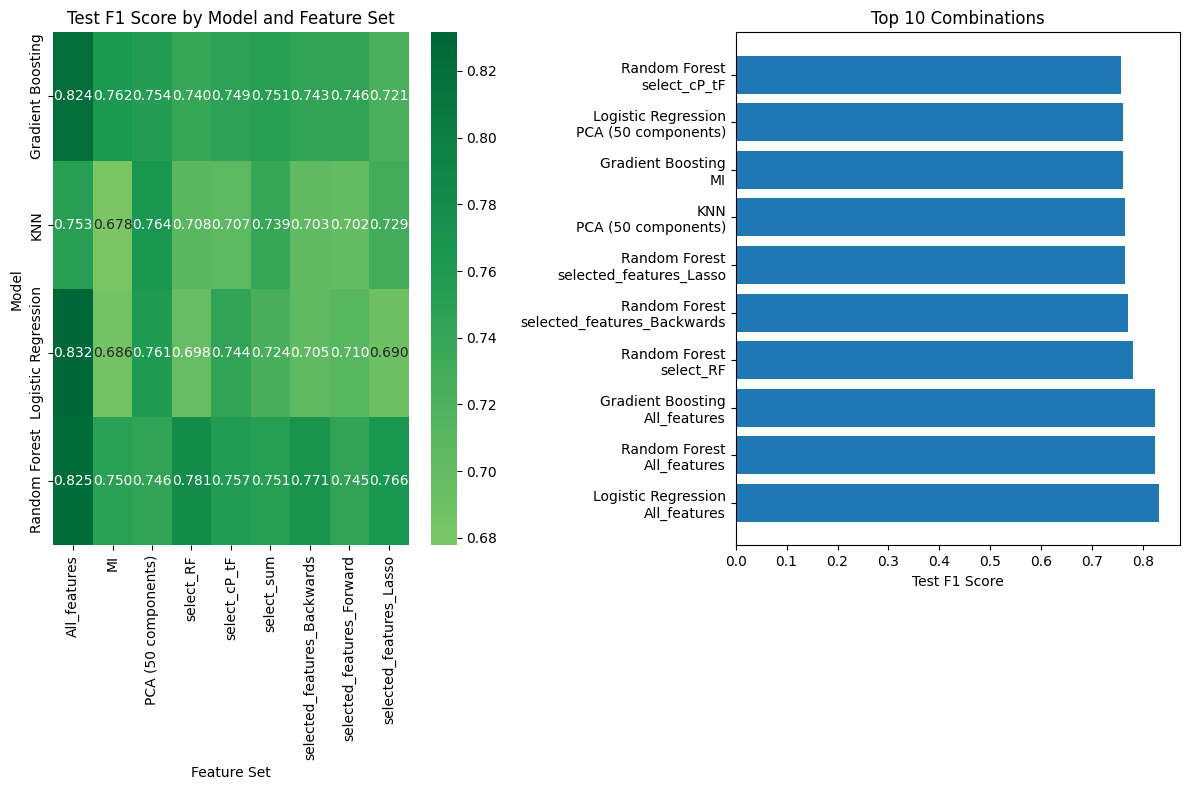


Visualization saved to 'classification_results_visualization.png'


In [ ]:
#Основная функция перебора моделей ипризнаков
# Получаем названия признаков
feature_names = X.columns.tolist()

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA baseline
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Список моделей для тестирования
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# Перебор подмножеств признаков для каждой модели
for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print('='*50)
    
    for name, feat_list in feature_sets.items():
        if len(feat_list) == 0:
            continue
        
        # Подмножество признаков
        if isinstance(feat_list, list) and len(feat_list) > 0:
            existing_features = [f for f in feat_list if f in X_train_df.columns]
            if len(existing_features) == 0:
                print(f"Warning: No features found for {name}")
                continue
            X_train_sub = X_train_df[existing_features].values
            X_test_sub = X_test_df[existing_features].values
        else:
            continue
        
        # Обучение модели
        model.fit(X_train_sub, y_train)
        y_pred = model.predict(X_test_sub)
        
        # Получаем вероятности для ROC-AUC
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
        else:
            y_pred_proba = None
        
        # Метрики
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # AUC-ROC
        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = None
        
        # Матрица ошибок
        cm = confusion_matrix(y_test, y_pred)
        
        # Кросс-валидация на train
        cv_scores = cross_val_score(model, X_train_sub, y_train, cv=5, scoring='accuracy')
        cv_f1_scores = cross_val_score(model, X_train_sub, y_train, cv=5, scoring='f1')
        
        results.append({
            'Model': model_name,
            'Feature Set': name,
            'n_features': len(existing_features),
            'CV Accuracy_mean': cv_scores.mean(),
            'CV Accuracy_std': cv_scores.std(),
            'CV F1_mean': cv_f1_scores.mean(),
            'CV F1_std': cv_f1_scores.std(),
            'Test Accuracy': accuracy,
            'Test Precision': precision,
            'Test Recall': recall,
            'Test F1': f1,
            'Test AUC': auc if auc is not None else np.nan,
            'Confusion Matrix': f"[[{cm[0,0]},{cm[0,1]}]\n [{cm[1,0]},{cm[1,1]}]]"
        })
        
        # Вывод прогресса
        if auc is not None:
            print(f"  {name}: F1={f1:.3f}, AUC={auc:.3f} (n={len(existing_features)})")
        else:
            print(f"  {name}: F1={f1:.3f}, AUC=N/A (n={len(existing_features)})")

# Добавляем PCA для каждой модели
print(f"\n{'='*50}")
print("Training with PCA...")
print('='*50)

for model_name, model in models.items():
    # Создаем копию модели для PCA
    model_pca = model.__class__(**model.get_params())
    model_pca.fit(X_train_pca, y_train)
    y_pred = model_pca.predict(X_test_pca)
    
    if hasattr(model_pca, 'predict_proba'):
        y_pred_proba = model_pca.predict_proba(X_test_pca)[:, 1]
    else:
        y_pred_proba = None
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = None
    
    cm = confusion_matrix(y_test, y_pred)
    
    cv_scores = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='accuracy')
    cv_f1_scores = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='f1')
    
    results.append({
        'Model': model_name,
        'Feature Set': 'PCA (50 components)',
        'n_features': 50,
        'CV Accuracy_mean': cv_scores.mean(),
        'CV Accuracy_std': cv_scores.std(),
        'CV F1_mean': cv_f1_scores.mean(),
        'CV F1_std': cv_f1_scores.std(),
        'Test Accuracy': accuracy,
        'Test Precision': precision,
        'Test Recall': recall,
        'Test F1': f1,
        'Test AUC': auc if auc is not None else np.nan,
        'Confusion Matrix': f"[[{cm[0,0]},{cm[0,1]}]\n [{cm[1,0]},{cm[1,1]}]]"
    })
    
    # Вывод прогресса для PCA
    if auc is not None:
        print(f"  {model_name} (PCA): F1={f1:.3f}, AUC={auc:.3f}")
    else:
        print(f"  {model_name} (PCA): F1={f1:.3f}, AUC=N/A")

# Создание DataFrame с результатами
results_df = pd.DataFrame(results)

# Создаем версию для отображения с форматированием
display_df = results_df.copy()

# Форматирование CV метрик с использованием apply с подачей данных - иначе ошибка, скорее всего можно сделать  проще(!)
def format_cv(row, metric):
    mean = row[f'CV {metric}_mean']
    std = row[f'CV {metric}_std']
    return f"{mean:.3f} ± {std:.3f}"

display_df['CV Accuracy'] = display_df.apply(lambda row: format_cv(row, 'Accuracy'), axis=1)
display_df['CV F1'] = display_df.apply(lambda row: format_cv(row, 'F1'), axis=1)

# Форматирование метрик
display_df['Test Accuracy'] = display_df['Test Accuracy'].apply(lambda x: f"{x:.3f}")
display_df['Test Precision'] = display_df['Test Precision'].apply(lambda x: f"{x:.3f}")
display_df['Test Recall'] = display_df['Test Recall'].apply(lambda x: f"{x:.3f}")
display_df['Test F1'] = display_df['Test F1'].apply(lambda x: f"{x:.3f}")
display_df['Test AUC'] = display_df['Test AUC'].apply(
    lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A"
)

# Сортировка по Test F1 (числовому)
results_df_sorted = results_df.sort_values('Test F1', ascending=False)

# Вывод результатов (с форматированием)
print("\n" + "="*100)
print("SUMMARY (sorted by Test F1)")
print("="*100)
sorted_display = display_df.loc[results_df_sorted.index]
print(sorted_display[['Model', 'Feature Set', 'n_features', 'CV Accuracy', 'CV F1', 
                      'Test Accuracy', 'Test F1', 'Test AUC']].to_string(index=False))

# Сводка по лучшей модели для каждого набора признаков
print("\n" + "="*100)
print("BEST MODEL FOR EACH FEATURE SET")
print("="*100)
best_per_features = results_df.loc[results_df.groupby('Feature Set')['Test F1'].idxmax()]
best_display = display_df.loc[best_per_features.index]
print(best_display[['Feature Set', 'Model', 'Test Accuracy', 'Test F1', 'Test AUC']].to_string(index=False))

# Топ-5 лучших комбинаций
print("\n" + "="*100)
print("TOP-5 BEST COMBINATIONS")
print("="*100)
top5 = results_df.nlargest(5, 'Test F1')
top5_display = display_df.loc[top5.index]
print(top5_display[['Model', 'Feature Set', 'n_features', 'Test F1', 'Test AUC', 'Test Accuracy']].to_string(index=False))

# Сохранение результатов (числовых)
results_df.to_csv('classification_results.csv', index=False)
print("\nResults saved to 'classification_results.csv'")

# Дополнительная статистика по лучшей модели
best_result = results_df.loc[results_df['Test F1'].idxmax()]
best_display_row = display_df.loc[best_result.name]
print("\n" + "="*100)
print(f"BEST MODEL: {best_result['Model']} with {best_result['Feature Set']}")
print("="*100)
print(f"Number of features: {best_result['n_features']}")
print(f"Test Accuracy: {best_display_row['Test Accuracy']}")
print(f"Test Precision: {best_display_row['Test Precision']}")
print(f"Test Recall: {best_display_row['Test Recall']}")
print(f"Test F1: {best_display_row['Test F1']}")
print(f"Test AUC: {best_display_row['Test AUC']}")
print(f"Confusion Matrix:\n{best_result['Confusion Matrix']}")

# Дополнительно: анализ по моделям
print("\n" + "="*100)
print("BEST result per model")
print("="*100)
best_per_model = results_df.loc[results_df.groupby('Model')['Test F1'].idxmax()]
best_per_model_display = display_df.loc[best_per_model.index]
print(best_per_model_display[['Model', 'Feature Set', 'n_features', 'Test F1', 'Test AUC']].to_string(index=False))

# Визуализация результатов (красивое :)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Создаем сводную таблицу для тепловой карты
pivot_table = results_df.pivot_table(
    values='Test F1', 
    index='Model', 
    columns='Feature Set'
)

plt.subplot(1, 2, 1)
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5)
plt.title('Test F1 Score by Model and Feature Set')

plt.subplot(1, 2, 2)
# Топ-10 комбинаций
top10 = results_df.nlargest(10, 'Test F1')
bars = plt.barh(range(len(top10)), top10['Test F1'].values)
plt.yticks(range(len(top10)), [f"{row['Model']}\n{row['Feature Set']}" for _, row in top10.iterrows()])
plt.xlabel('Test F1 Score')
plt.title('Top 10 Combinations')

plt.tight_layout()
plt.savefig('classification_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nVisualization saved to 'classification_results_visualization.png'")

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV

# Выбранные признаки
zero_var_cols = X.columns[X.var(numeric_only=True) == 0] #выделим признаки с 0 дисперсией, так как  возможно по этой причине вылетают warnings  
                                                         #при операции с матрицами - но это не помогло 

selected_features = X.columns.tolist()
selected_features = [c for c in selected_features if c not in set(zero_var_cols)]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


# Стандартизация (обязательно для лог регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Используем {len(selected_features)} признаков")


#Перебор параметров
# Сетка параметров
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Grid Search
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

# Итоги
print("\n" + "="*50)
print("РЕЗУЛЬТАТ")
print("="*50)

best_model = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"CV F1: {grid_search.best_score_:.4f}")

# Оценка на тесте
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nТестовая оценка:")
print(f"  F1: {f1:.4f}")
print(f"  AUC: {auc:.4f}")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Confusion Matrix:\n{cm}")


# Выведем важные признаки
coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nТоп-10 признаков:")
print(coefficients.head(10).to_string(index=False))



Train: (775, 193), Test: (194, 193)
Используем 193 признаков
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kocenkovaelena/MIFI/venv/lib/python3.9/site-packages/sklearn/util


РЕЗУЛЬТАТ
Лучшие параметры: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
CV F1: 0.8004

Тестовая оценка:
  F1: 0.8191
  AUC: 0.9126
  Accuracy: 0.8247
  Confusion Matrix:
[[83 15]
 [19 77]]

Топ-10 признаков:
           Feature  Coefficient
            fr_NH2     0.819466
       EState_VSA9     0.744763
fr_alkyl_carbamate     0.721648
       VSA_EState8     0.600595
       SlogP_VSA10     0.573825
        SlogP_VSA3     0.556673
           MolLogP     0.546989
   fr_allylic_oxid     0.532448
          fr_Ar_OH     0.488382
        fr_sulfide     0.470696


Выбранная лучшая комбинация модель + подмножество признаков - Logistic Regression + All_features F1 = 0.832, AUC = 0.904

Тестовая оценка на модели  после отбора гепирпараметров:

F1: 0.8191

AUC: 0.9126